# Section 1: Environment Setup

In [16]:
using Pkg

# The examples environment already points to the local package via
# [sources] EOptInterface = { path = ".." }, so avoid mutating the env
# from inside the notebook kernel.
ENV["JULIA_PKG_PRECOMPILE_AUTO"] = "0"
ENV["JULIA_NUM_PRECOMPILE_TASKS"] = "1"

function _pid_is_alive(pid::Integer)
    pid <= 0 && return false
    rc = ccall(:kill, Cint, (Cint, Cint), pid, 0)
    return rc == 0 || Base.Libc.errno() == Base.Libc.EPERM
end

function _clear_stale_precompile_pidfiles!()
    compiled_root = joinpath(homedir(), ".julia", "compiled", "v$(VERSION.major).$(VERSION.minor)")
    isdir(compiled_root) || return nothing
    for (root, _, files) in walkdir(compiled_root)
        for file in files
            endswith(file, ".pidfile") || continue
            pidfile = joinpath(root, file)
            text = try
                strip(read(pidfile, String))
            catch
                ""
            end
            pid = try
                parse(Int, split(text)[1])
            catch
                0
            end
            _pid_is_alive(pid) && continue
            rm(pidfile; force = true)
        end
    end
    return nothing
end

_clear_stale_precompile_pidfiles!()

function _find_repo_root()
    candidates = String[
        pwd(),
        normpath(joinpath(pwd(), "..")),
        normpath(joinpath(@__DIR__, "..")),
    ]
    for root in unique(candidates)
        if isfile(joinpath(root, "src", "EOptInterface.jl")) && isfile(joinpath(root, "examples", "Project.toml"))
            return root
        end
    end
    error("Could not locate the EOptInterface repo root from the current notebook session.")
end

repo_root = _find_repo_root()
examples_env = joinpath(repo_root, "examples")
examples_project = joinpath(examples_env, "Project.toml")

function _latest_mtime(root::AbstractString)
    isdir(root) || return 0.0
    latest = 0.0
    for (dir, _, files) in walkdir(root)
        for file in files
            latest = max(latest, stat(joinpath(dir, file)).mtime)
        end
    end
    return latest
end

function _precompile_stamp_path(env::AbstractString)
    return joinpath(env, ".notebook_precompile_v$(VERSION.major).$(VERSION.minor).stamp")
end

function _precompile_signature(repo_root::AbstractString, examples_env::AbstractString)
    mtimes = Float64[
        isfile(joinpath(examples_env, "Project.toml")) ? stat(joinpath(examples_env, "Project.toml")).mtime : 0.0,
        isfile(joinpath(examples_env, "Manifest.toml")) ? stat(joinpath(examples_env, "Manifest.toml")).mtime : 0.0,
        _latest_mtime(joinpath(repo_root, "src")),
    ]
    return string(VERSION, '|', maximum(mtimes))
end

function _ensure_examples_precompiled!(repo_root::AbstractString, examples_env::AbstractString)
    script = joinpath(repo_root, "examples", "precompile_examples_env.jl")
    isfile(script) || return nothing
    stamp_path = _precompile_stamp_path(examples_env)
    signature = _precompile_signature(repo_root, examples_env)
    cached_signature = try
        strip(read(stamp_path, String))
    catch
        ""
    end
    cached_signature == signature && return nothing
    println("Precompiling examples environment before Section 2...")
    run(`$(Base.julia_cmd()) --project=$(examples_env) $(script)`)
    write(stamp_path, signature * "\n")
    return nothing
end

# Set this to true only when bootstrapping a fresh examples environment.
bootstrap_examples_env = false

if Base.active_project() != examples_project
    Pkg.activate(examples_env; io = devnull)
end

if bootstrap_examples_env || !isfile(joinpath(examples_env, "Manifest.toml"))
    Pkg.instantiate(; io = devnull)
end

_ensure_examples_precompiled!(repo_root, examples_env)
println("Active project: ", Base.active_project())


Active project: /Volumes/Lexar/Dropbox/Research/Wastewater Treatment/Wastewater Treatment Repo/EOptInterface/EOptInterface.jl/examples/Project.toml


# Section 2: Imports + Model Initialization

In [17]:
using EOptInterface
using ModelingToolkit, Unitful, IfElse, NativeNaNMath
using ModelingToolkit: t_nounits as t, D_nounits as D
using OrdinaryDiffEq, DiffEqCallbacks
using Logging

uconn_asm3_mod = Module(:UConnASM3NotebookModel)
Core.eval(uconn_asm3_mod, :(eval(x) = Core.eval($uconn_asm3_mod, x)))
Core.eval(uconn_asm3_mod, :(include(path::AbstractString) = Base.include($uconn_asm3_mod, path)))
with_logger(Logging.NullLogger()) do
    Base.include(uconn_asm3_mod, joinpath(@__DIR__, "uconn_wrrf_asm3", "ASM3_UConn_BNR_Unit_CSTR_Emulation.jl"))
end

sys = getfield(uconn_asm3_mod, :sys)
sol = getfield(uconn_asm3_mod, :sol)
Ini2vecflow = getfield(uconn_asm3_mod, :Ini2vecflow)

# Access reactor subsystems for later use.
reactor2 = sys.reactor2
reactor4 = sys.reactor4


Model reactor4:
Subsystems (2): see hierarchy(reactor4)
  In
  Out
Equations (76):
  76 standard: see equations(reactor4)
Unknowns (95): see unknowns(reactor4)
  (x(t))[1] [defaults to NoValue()]
  (x(t))[2] [defaults to NoValue()]
  (x(t))[3] [defaults to NoValue()]
  (x(t))[4] [defaults to NoValue()]
  ⋮
Parameters (107): see parameters(reactor4)
  k_H_c[1] [defaults to 2]
  k_H_c[2] [defaults to 3]
  K_X_c[1] [defaults to 1]
  K_X_c[2] [defaults to 1]
  ⋮

# Section 3: MPC Controller (Config + Build + Step)

We set up two different struct, one for the MPC-->MPCConfig base setup:
1. prediction horizon,
2. control horizon
3. the time step
4. For the setpoint tracking problem
    We have the a. setpoint(sp) b. slack penalty ($\rho$) (to stablize the MPC to make it not overshoot or make it converge quickly) c. The smoothness penalty Rsm on the control variable ($\delta u$). d. penalty on first-step move from u_prev (R1), this variable is introduced into the objective function that could add penalty to the control variable change to prevent the control variable oscillation in the steady state. e. terminal weight multiplier, this is a terminal weight adjustment coefficient to make sure that the terminal setpoint is considered enough in the objective function.  

In [18]:
with_logger(Logging.NullLogger()) do
    include(joinpath(@__DIR__, "uconn_wrrf_asm3", "ASM3_MPC_Utilities.jl"))
end

MPCConfig()


MPCConfig(20, 10, 0.2, 3.0, 4000.0, 5.0, 10.0, 2.0, 0.0, 0.03, 1000.0, 0.0, 400.0, 200.0, true, 3, "[MPC]", :stderr, false)

    build_controller(sys, sol; cfg=MPCConfig(), y_sym=sys.reactor5.x[4])

Build a JuMP+Ipopt MPC model ONCE.

- `sys`   : ModelingToolkit ODE system (from the ASM3 source file)
- `sol`   : a reference solution object used to initialize IC constraints (provided by the calling script)
- `cfg`   : MPCConfig (horizons, penalties, bounds, etc.)
- `y_sym` : tracked symbolic variable, default `sys.reactor5.x[4]`

Returns:
- `ctrl::MPCController`
- `u0_dict` initial condition map (for ODEProblem)

In [19]:
build_controller


build_controller (generic function with 1 method)

# Section 4: Closed-Loop MPC Rollout


Starting closed-loop UConn ASM3 MPC...


[MPC] t=0.000 | status=LOCALLY_SOLVED | accepted=true | obj=35901.019 | SNH4=7.478 (sp=3.000) | KLa2=243.604 | KLa4=243.571
[MPC] t=0.200 | status=LOCALLY_SOLVED | accepted=true | obj=21754.476 | SNH4=1.384 (sp=3.000) | KLa2=250.491 | KLa4=250.337
[MPC] t=0.400 | status=LOCALLY_SOLVED | accepted=true | obj=17491.277 | SNH4=2.722 (sp=3.000) | KLa2=263.036 | KLa4=262.617
[MPC] t=0.600 | status=LOCALLY_SOLVED | accepted=true | obj=16925.356 | SNH4=3.378 (sp=3.000) | KLa2=274.557 | KLa4=273.915
[MPC] t=0.800 | status=LOCALLY_SOLVED | accepted=true | obj=15288.155 | SNH4=3.614 (sp=3.000) | KLa2=285.005 | KLa4=284.185
[MPC] t=1.000 | status=LOCALLY_SOLVED | accepted=true | obj=12393.301 | SNH4=3.634 (sp=3.000) | KLa2=294.353 | KLa4=293.397
[MPC] t=1.200 | status=LOCALLY_SOLVED | accepted=true | obj=9324.581 | SNH4=3.558 (sp=3.000) | KLa2=302.564 | KLa4=301.510
[MPC] t=1.400 | status=LOCALLY_SOLVED | accepted=true | obj=6564.392 | SNH4=3.447 (sp=3.000) | KLa2=309.681 | KLa4=308.562
[MPC] t=1.

Row,time,setpoint,SNH4,KLa2,KLa4
,Float64,Float64,Float64,Float64,Float64
1,8.2,2.0,1.99998,383.586,383.404
2,8.4,2.0,1.99971,383.583,383.401
3,8.6,2.0,1.99994,383.567,383.385
4,8.8,2.0,2.00001,383.57,383.387
5,9.0,2.0,2.00003,383.571,383.389
6,9.2,2.0,2.00001,383.571,383.389
7,9.4,2.0,1.99979,383.571,383.389
8,9.6,2.0,1.99992,383.56,383.377
9,9.8,2.0,2.00041,383.56,383.377


final solve status = LOCALLY_SOLVED
final objective = 1.724


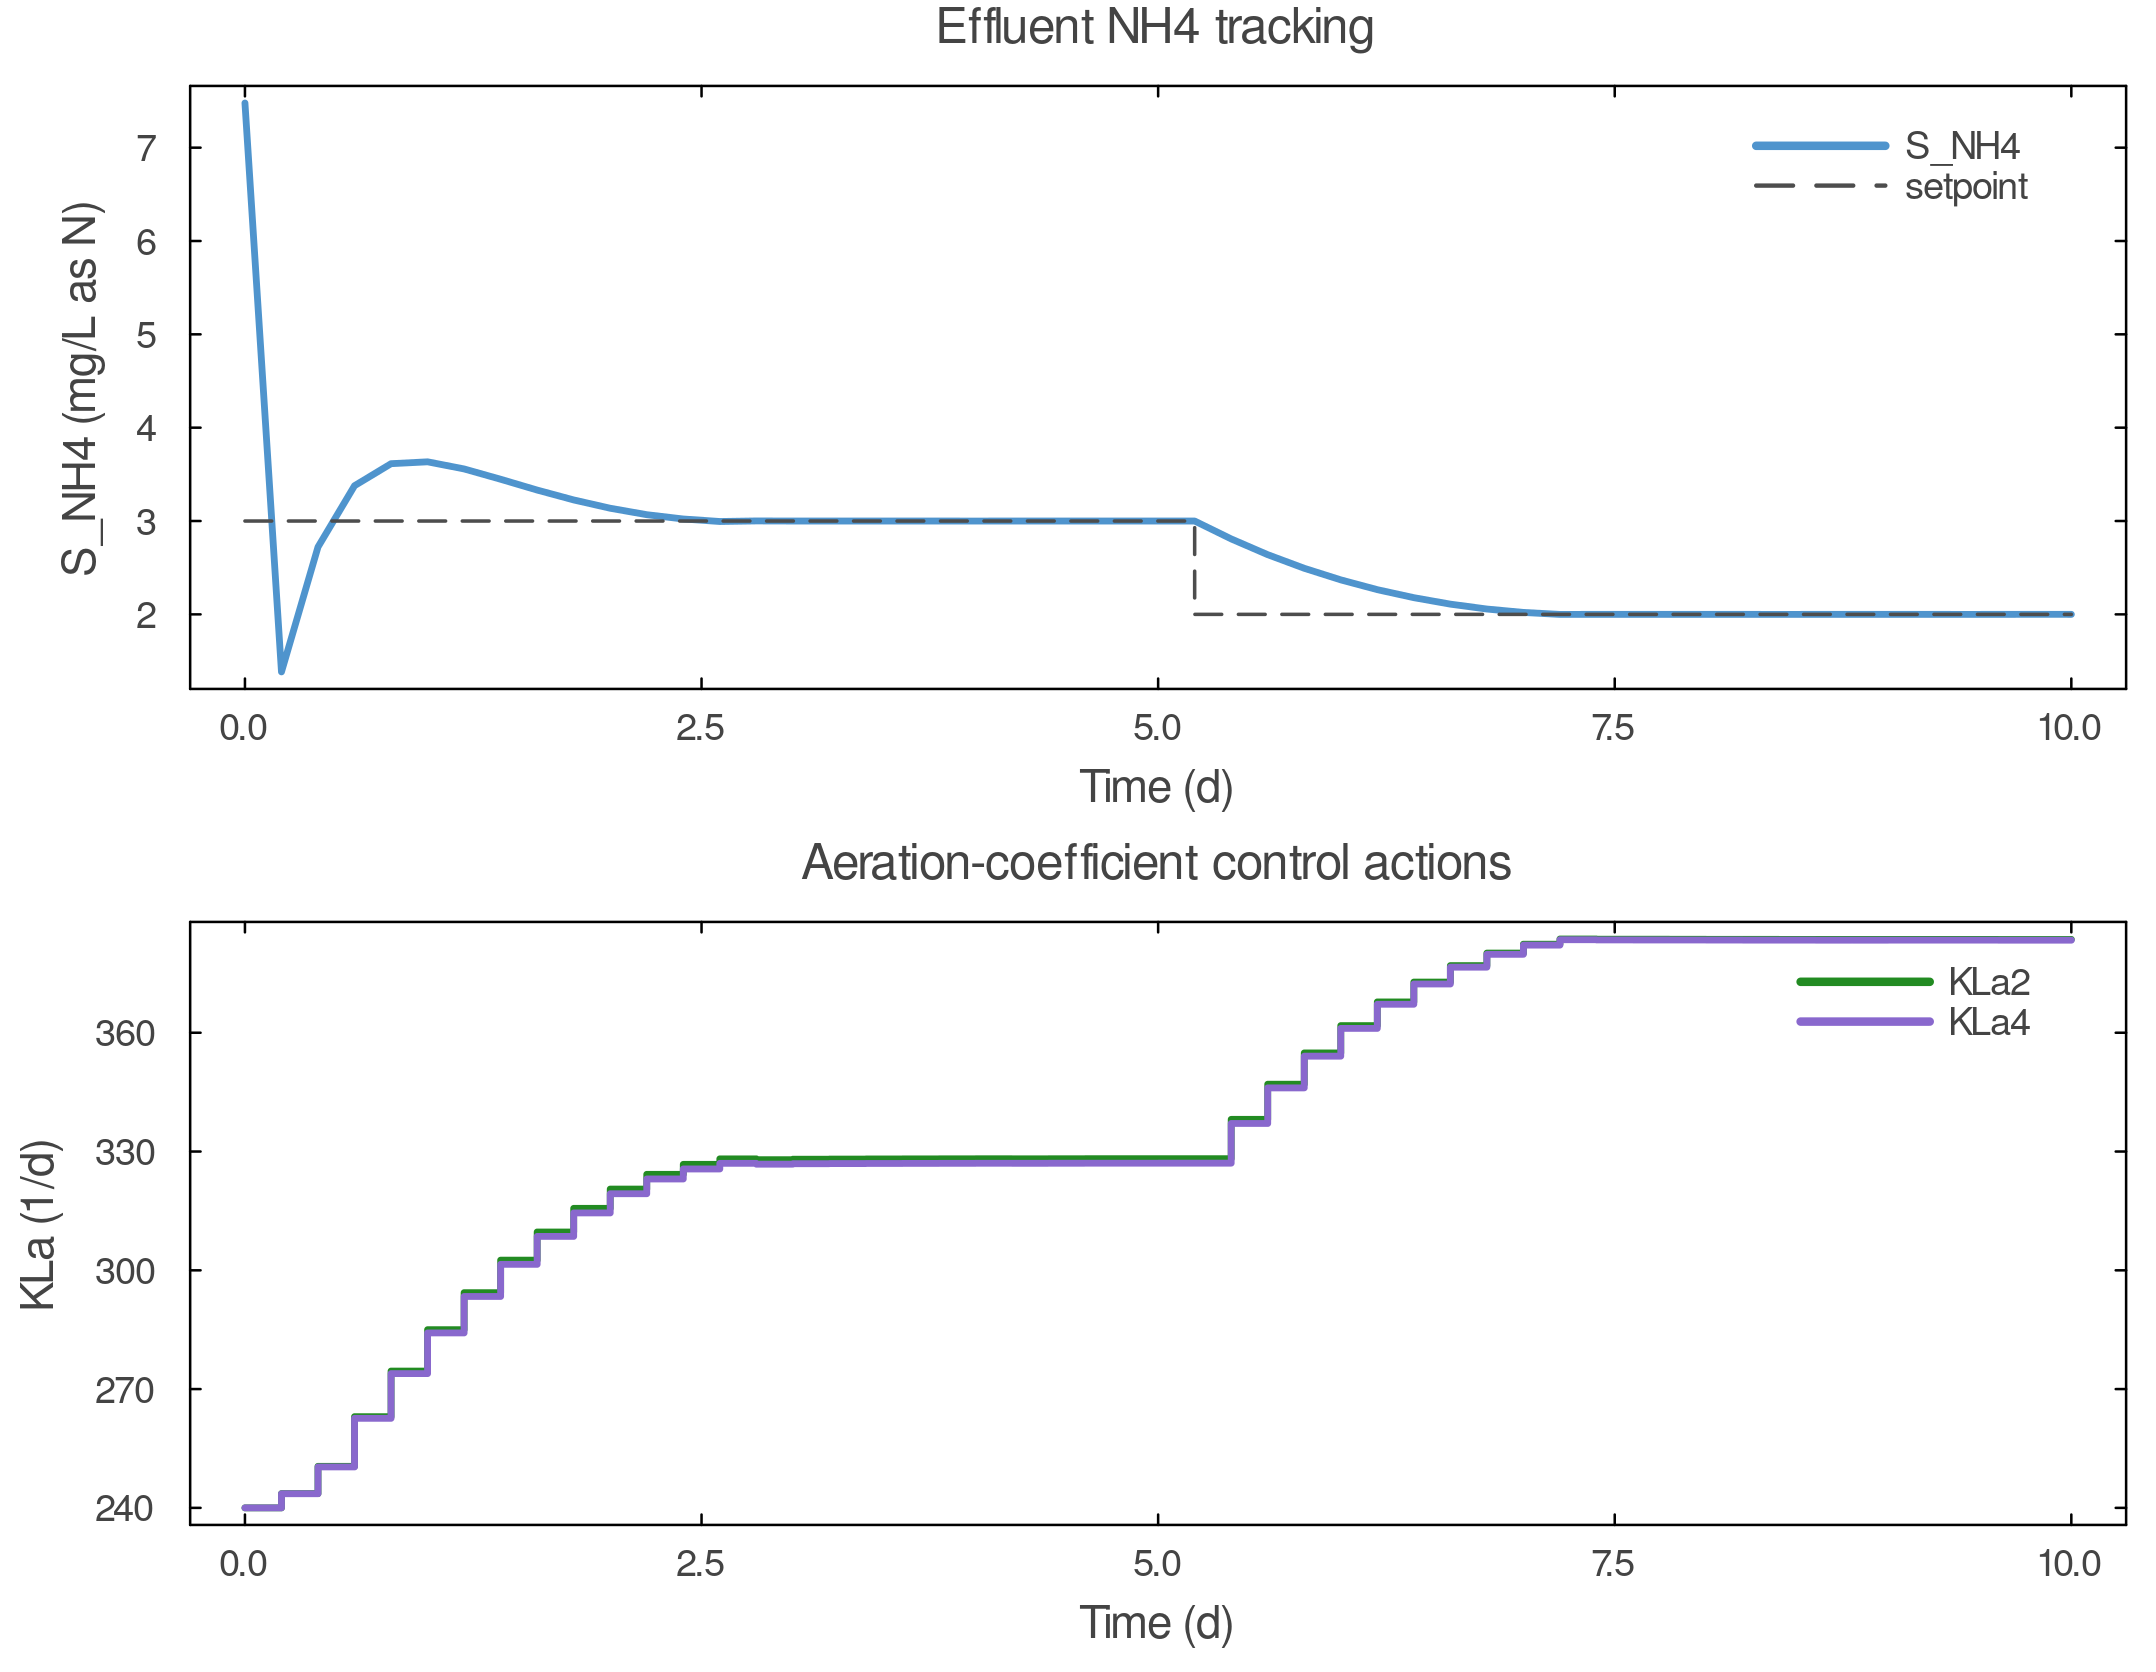

In [20]:
include(joinpath(repo_root, "notebooks", "eoi_publication_plots.jl"))
apply_eoi_publication_style!()

println("Starting closed-loop UConn ASM3 MPC...")
flush(stderr)
cfg_hi = MPCConfig(show_status = true, status_stream = :stderr, verbose = false)
cfg_lo = MPCConfig(sp = 2.0, show_status = true, status_stream = :stderr, verbose = false)
uconn_closed_loop = run_uconn_closed_loop_mpc(sys, sol; cfg_hi = cfg_hi, cfg_lo = cfg_lo)
println("final solve status = ", isempty(uconn_closed_loop.log.statuses) ? "n/a" : last(uconn_closed_loop.log.statuses))
println("final objective = ", isempty(uconn_closed_loop.log.objectives) ? NaN : round(last(uconn_closed_loop.log.objectives); digits=3))
display(last(uconn_closed_loop.log_df, min(10, nrow(uconn_closed_loop.log_df))))
asm3_plot_closed_loop_pair(uconn_closed_loop.log_df)
